# Single-Cell DDR Programs in the Breast Tumour Microenvironment
Independent reanalysis of the Wu et al. (2021) breast cancer atlas (GSE176078; 100,000 cells, 26 patients). A standard single-cell RNA-seq pipeline is run from raw counts, validated against the published annotations, and used to score DNA-damage-response (DDR) gene-program activity across the tumour microenvironment.

## 1. Load and inspect data
Prior to processing, the dataset is characterised to establish four properties required by the pipeline: (1) its dimensions; (2) the location of the raw counts, since CELLxGENE stores the authors' normalised data in `adata.X` and the raw counts in `adata.raw.X`, and the pipeline must be initialised from raw counts; (3) the gene-identifier scheme (Ensembl IDs, with symbols in `feature_name`), required for DDR scoring; and (4) the available annotations, namely the cell-type column (`celltype_major`, used for validation) and the patient column (`donor_id`, required for Harmony integration across the 26 patients).

In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import harmonypy
import decoupler as dc
import seaborn as sns
import matplotlib.pyplot as plt
import gseapy as gp
from scipy.stats import hypergeom
from statsmodels.stats.multitest import multipletests
from scipy.stats import hypergeom
from collections import Counter
import celltypist
from celltypist import models

/Users/sneha/anaconda3/envs/scrna/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
adata = sc.read_h5ad("../data/raw/breast_atlas.h5ad")
adata

AnnData object with n_obs × n_vars = 100064 × 28468
    obs: 'donor_id', 'percent_mito', 'nCount_RNA', 'nFeature_RNA', 'celltype_major', 'celltype_minor', 'celltype_subset', 'subtype', 'gene_module', 'calls', 'normal_cell_call', 'CNA_value', 'batch_run', 'multiplexed', 'cryo_state', 'development_stage_ontology_term_id', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH', 'HER2_ISH_ratio', 'Ki67', 'subtype_by_IHC', 'treatment_status', 'treatment_details', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'disease_ontology_term_id', 'grade', 'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'is_pre_analysis', 'organism', 'organism

The object is first surveyed to establish its dimensions, the metadata columns present, whether the authors retained any embeddings, and, importantly, whether a `.raw` slot exists as the likely source of raw counts.

In [3]:
print("Shape (cells, genes):", adata.shape)            # how many cells x genes
print("\nobs columns:", adata.obs.columns.tolist())    # per-CELL metadata (cell types, patient, subtype...)
print("\nvar columns:", adata.var.columns.tolist())    # per-GENE metadata (gene names, biotype...)
print("layers:", list(adata.layers.keys()))            # any alternative matrices stored
print("obsm (embeddings):", list(adata.obsm.keys()))   # any precomputed PCA/UMAP the authors left
print("raw present?:", adata.raw is not None)          # is there a .raw snapshot? (likely the raw counts)

Shape (cells, genes): (100064, 28468)

obs columns: ['donor_id', 'percent_mito', 'nCount_RNA', 'nFeature_RNA', 'celltype_major', 'celltype_minor', 'celltype_subset', 'subtype', 'gene_module', 'calls', 'normal_cell_call', 'CNA_value', 'batch_run', 'multiplexed', 'cryo_state', 'development_stage_ontology_term_id', 'cancer_type', 'ER', 'PR', 'HER2_IHC', 'HER2_ISH', 'HER2_ISH_ratio', 'Ki67', 'subtype_by_IHC', 'treatment_status', 'treatment_details', 'assay_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'disease_ontology_term_id', 'grade', 'cell_type_ontology_term_id', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid']

var columns: ['feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type']
layers: []
obsm (embeddings): ['X_Three-D', 'X_umap']
raw pre

Identifying the location of the raw counts is a critical preliminary step. The pipeline is initialised from raw counts; CELLxGENE, however, stores the authors' normalised data in `adata.X` and the raw counts in `adata.raw.X`. The two matrices are distinguished by their maximum value: approximately 9 for `adata.X` (small and fractional, indicating normalised and log-transformed data) versus approximately 29,831 for `adata.raw.X` (large integers, indicating raw counts). The raw counts therefore reside in `adata.raw.X`, which is used as the pipeline input. The `hasattr` checks determine whether each matrix is sparse or dense for display purposes, and the `if adata.raw is not None` guard prevents an error when no raw slot is present.

In [4]:
# Look at adata.X, is it raw counts, or already normalized by the authors?
print("X, first 3x5, max:")
print(adata.X[:3, :5].toarray() if hasattr(adata.X, "toarray") else adata.X[:3, :5]) # peek; handle sparse OR dense
print("X max:", adata.X.max())  # small max (~9) => normalized/log data; large integer max => raw counts

# Look at adata.raw.X, where CELLxGENE usually stores the RAW counts
if adata.raw is not None:       # only if a raw snapshot exists (guards against a crash)
  print("\nraw.X, first 3x5, max:")
  print(adata.raw.X[:3, :5].toarray() if hasattr(adata.raw.X, "toarray") else adata.raw.X[:3, :5])
  print("raw.X max:", adata.raw.X.max())  # large integer max (~29831) => these are the RAW counts

X, first 3x5, max:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
X max: 9.111652

raw.X, first 3x5, max:
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
raw.X max: 29831.0


In [5]:
adata.var.head()

,feature_is_filtered,feature_name,feature_reference,feature_biotype,feature_length,feature_type
ENSG00000279928,False,DDX11L17,NCBITaxon:9606,gene,570,transcribed_unprocessed_pseudogene
ENSG00000279457,False,WASH9P,NCBITaxon:9606,gene,1397,transcribed_unprocessed_pseudogene
ENSG00000228463,False,ENSG00000228463,NCBITaxon:9606,gene,457,transcribed_processed_pseudogene
ENSG00000237094,False,ENSG00000237094,NCBITaxon:9606,gene,183,transcribed_unprocessed_pseudogene
ENSG00000230021,False,ENSG00000230021,NCBITaxon:9606,gene,183,transcribed_processed_pseudogene


The two columns on which the pipeline depends are the cell-type annotation (`celltype_major`, used to validate the clusters) and the patient column (`donor_id`, the input to Harmony). The loop reports only the relevant columns rather than the full set of approximately thirty.

In [6]:
for col in adata.obs.columns:
  low = col.lower()
  if any(k in low for k in ["cell", "type", "cluster", "patient", "donor", "sample", "subtype"]):
      print(f"=== {col} === ({adata.obs[col].nunique()} unique)") 
      print(adata.obs[col].value_counts().head(12), "\n")

=== donor_id === (26 unique)
donor_id
CID4471     8609
CID44971    7986
CID4495     7985
CID44991    7023
CID3586     6178
CID4290A    5789
CID4513     5619
CID4066     5309
CID4398     4451
CID4530N    4409
CID4515     4149
CID4535     3961
Name: count, dtype: int64 

=== celltype_major === (9 unique)
celltype_major
T-cells              35214
Cancer Epithelial    24489
Myeloid               9675
Endothelial           7605
CAFs                  6573
PVL                   5423
Normal Epithelial     4355
Plasmablasts          3524
B-cells               3206
Name: count, dtype: int64 

=== celltype_minor === (29 unique)
celltype_minor
T cells CD4+          19231
T cells CD8+          11487
Cancer LumA SC         7742
Macrophage             5929
Cancer Cycling         5359
Endothelial ACKR1      4611
Cancer Basal SC        4312
Cancer Her2 SC         3708
Plasmablasts           3524
PVL Differentiated     3487
CAFs myCAF-like        3420
Cancer LumB SC         3368
Name: count, dtype: int6

## 2. Building the working object from raw counts
`adata.X` holds the authors' normalised data, whereas the pipeline operates on raw counts (`adata.raw.X`). `.raw.to_adata()` rebuilds the object with raw counts as `X` while preserving the cell annotations (`obs`), retaining the published cell types and patient labels. The gene index is then converted from Ensembl IDs to gene symbols (`feature_name`) so that mitochondrial genes (`MT-`) can be flagged and DDR genes (for example TP53 and BRCA1) scored by name.

In [7]:
# Rebuild adata with raw counts as X (preserves obs: cell types + patient labels)
adata = adata.raw.to_adata()

In [8]:
# Gene names are Ensembl IDs; swap to readable symbols so MT-flagging and DDR scoring work by name.
adata.var["ensemble_id"] = adata.var_names   # keep Ensembl IDS in a column
adata.var_names = adata.var["feature_name"].astype(str)  # use gene symbols as the index
adata.var_names_make_unique()        # avoid duplicate gene names

# Verify
print(f"X max (expect raw counts ~29831): {adata.X.max()}")
print(f"Shape: {adata.shape}")
print(f"var columns: {adata.var.columns.tolist()}")
adata.var.head()

X max (expect raw counts ~29831): 29831.0
Shape: (100064, 28468)
var columns: ['feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'ensemble_id']


,feature_name,feature_reference,feature_biotype,feature_length,feature_type,ensemble_id
feature_name,,,,,,
DDX11L17,DDX11L17,NCBITaxon:9606,gene,570,transcribed_unprocessed_pseudogene,ENSG00000279928
WASH9P,WASH9P,NCBITaxon:9606,gene,1397,transcribed_unprocessed_pseudogene,ENSG00000279457
ENSG00000228463,ENSG00000228463,NCBITaxon:9606,gene,457,transcribed_processed_pseudogene,ENSG00000228463
ENSG00000237094,ENSG00000237094,NCBITaxon:9606,gene,183,transcribed_unprocessed_pseudogene,ENSG00000237094
ENSG00000230021,ENSG00000230021,NCBITaxon:9606,gene,183,transcribed_processed_pseudogene,ENSG00000230021


## 3. Quality control
In a standard single-cell RNA-seq workflow, cells are filtered on three signals, with thresholds chosen from the observed distributions rather than from fixed defaults:
- Low gene or total-count values indicate empty droplets or low-quality cells and motivate a lower bound (for example, at least 200 genes per cell).
- Very high gene or total-count values indicate likely doublets (two cells captured together) and motivate an upper bound.
- A high mitochondrial fraction indicates stressed or dying cells, in which the membrane ruptures and cytoplasmic RNA is lost while the mitochondrial fraction rises, and motivates an upper bound (commonly 10 to 20%, with higher values permitted for tumour tissue).

In [9]:
# Flag mitochondrial genes (human MT- prefix). A high mito fraction marks stressed/dying cells.
adata.var["mt"] = adata.var_names.str.startswith("MT-")
print("Mitochondrial genes flagged:",adata.var["mt"].sum())

# Compute per-cell QC metrics (and the mito-specific fraction via qc_vars).
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True, percent_top=None)
adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe()

Mitochondrial genes flagged: 13


,n_genes_by_counts,total_counts,pct_counts_mt
count,100064.000000,100064.000000,100064.000000
mean,1772.656190,7125.463379,6.085261
std,1339.605016,9931.045898,3.971120
min,199.000000,250.000000,0.000000
25%,816.000000,1918.000000,3.187200
50%,1335.500000,3564.000000,5.156137
75%,2327.000000,7947.000000,8.115371
max,10274.000000,181422.000000,20.626631


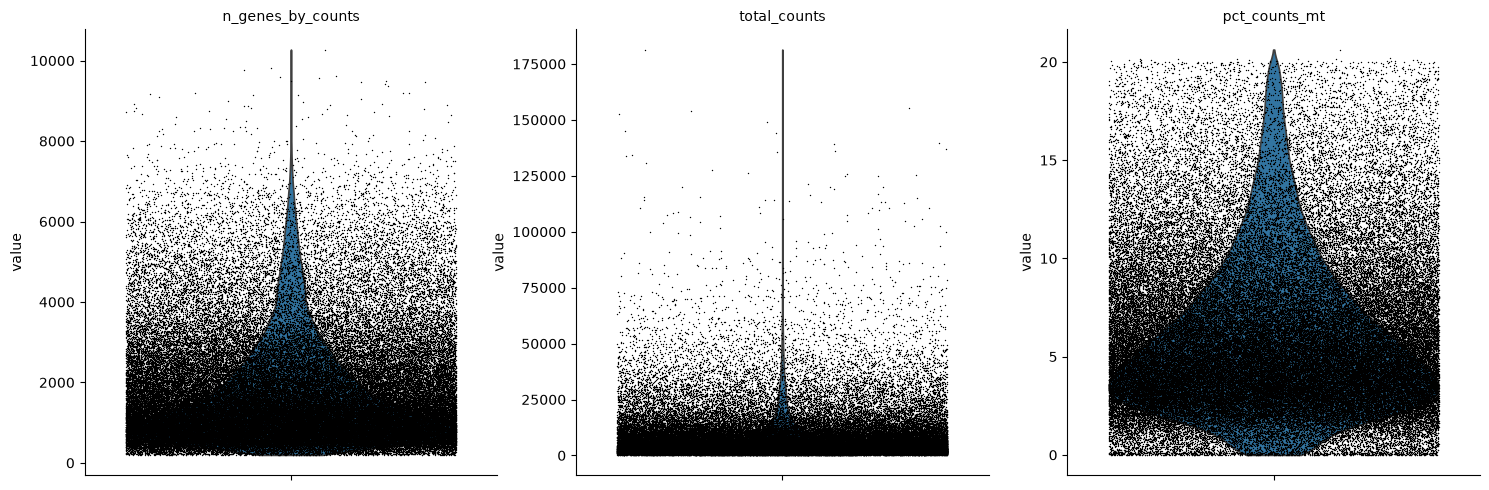

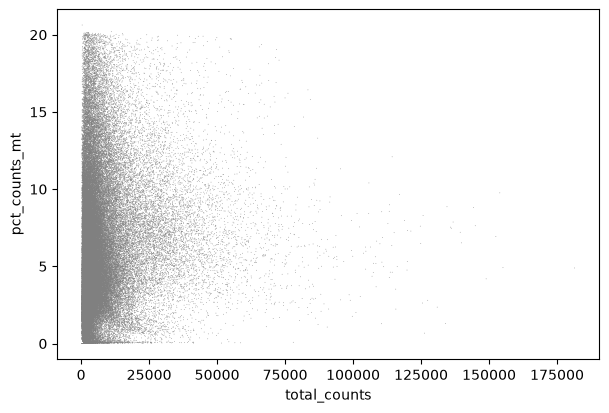

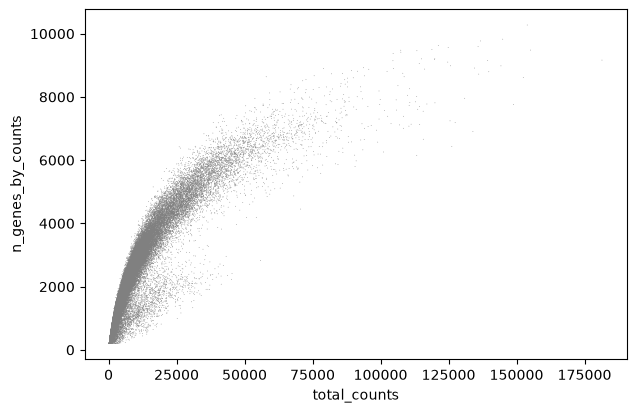

In [10]:
# Violin: see where the healthy bulk of cells sits vs the outlier tails.
sc.pl.violin(adata, ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
            jitter = 0.4, multi_panel=True)

# Scatter: high mito + low counts = dying cells (top-left); counts vs genes should track tightly.
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")

The dataset has already been quality-controlled by the original authors, as is evident from the `pct_counts_mt` distribution, which is capped at approximately 20% (the authors' mitochondrial cutoff) with no cells above it. The obvious empty droplets, doublets, and dying cells have therefore already been removed, which is why the distributions show no clear low-quality tail.

Because the data are pre-cleaned, aggressive filtering would discard valid cells. Only light confirmatory thresholds are therefore applied (at least 200 genes per cell; genes detected in at least 3 cells; mitochondrial fraction below 20%) to document the criteria, and the analysis proceeds. Full quality-control decision-making on genuinely raw data, including threshold selection from a clear low-quality tail, is demonstrated separately in `00_explore.ipynb` (PBMC3k).

In [11]:
print("Before QC:", adata.shape) 
sc.pp.filter_cells(adata, min_genes=200)             # lower bound: drop near-empty cells
sc.pp.filter_genes(adata, min_cells=3)               # drop genes detected in <3 cells (noise)
adata = adata[adata.obs.pct_counts_mt < 20].copy()   # authors' mito cutoff (confirmatory)
print("After QC:", adata.shape)

Before QC: (100064, 28468)
After QC: (100028, 26622)


Light confirmatory filtering removed 36 low-quality cells and 1,846 rarely-detected genes (100,064 to 100,028 cells; 28,468 to 26,622 genes), consistent with prior quality control by the original authors. The cleaned data proceed to normalisation.

## 4. Normalisation
Cells capture different total numbers of molecules for purely technical reasons (capture efficiency, sequencing depth, cell size), so raw counts are not comparable across cells. This is corrected in two steps:
- Normalisation (`normalize_total`, `target_sum=1e4`) rescales each cell so that its counts sum to 10,000 (counts per 10,000, CP10K), removing differences in sequencing depth so that cells become comparable.
- Log-transformation (`log1p`) applies log(1 + x). This compresses the wide expression range, limits the influence of a small number of high-count genes, and converts multiplicative differences into additive ones; the +1 leaves zeros unchanged (log(1) = 0). The result is log-normalised data, the standard input for feature selection and dimensionality reduction.

In [12]:
# Normalize each cell to 10,000 total counts (CP10K), makes cells comparable across sequencing depth.
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform: log(1 + x). Compresses the range, reduces the dominance of high-count genes;
# the +1 keeps zeros as zeros (log(1)=0). adata.X is now log-normalized.
sc.pp.log1p(adata)

# Confirm: a small max (single digits) is the signature of log-normalized data.
print("Max after normalize + log:", adata.X.max())

Max after normalize + log: 9.111652


## 5. Highly variable genes
Most genes are expressed at similar levels across all cells and provide little information for distinguishing cell types. The 2,000 most variable genes are retained to focus downstream steps on biological signal. Because the dataset spans 26 patients, highly variable genes are selected in a batch-aware manner (`batch_key="donor_id"`) so that the selection is not dominated by any single patient. Before subsetting, the full log-normalised matrix is stored in `adata.raw`, so that all genes, including DDR genes outside the top 2,000, remain available for scoring and plotting.

In [13]:
# Select the 2,000 most variable genes, computed per-patient (batch-aware) so no single
# patient dominates the selection.
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="donor_id")
print("HIghly variable genes:", adata.var["highly_variable"].sum())

# Freeze the full log-normalized matrix (ALL genes) so DDR genes stay accessible later,
# even after X is subset to the HVGs.
adata.raw = adata

# Subset to the highly variable genes for dimensionality reduction.
adata = adata[:, adata.var.highly_variable].copy()
print("Shape after HVG subset:", adata.shape)   # (cells, 2000)

HIghly variable genes: 2000
Shape after HVG subset: (100028, 2000)


## 6. Scaling, PCA, and Harmony integration
- Scaling (`scale`, `max_value=10`) standardises each gene to mean 0 and unit variance so that highly expressed genes do not dominate PCA by magnitude, with extreme values capped at 10.
- PCA (50 components) compresses the 2,000 genes into 50 principal components, a denoised per-cell representation. More components are used than in the PBMC walkthrough because this tumour atlas contains many more cell types and states.
- Batch integration (`harmony_integrate`, `key="donor_id"`) corrects the batch effects introduced by the 26 patients; without correction, cells would cluster by patient rather than by cell type. Harmony uses the patient labels to align matching cell types across patients, producing a corrected embedding (`X_pca_harmony`) used by all downstream steps.

In [14]:
# Standardize each gene (mean 0, variance 1; cap at 10) so no gene dominates PCA by magnitude.
sc.pp.scale(adata, max_value=10)

# PCA: compress 2,000 genes -> 50 components (denoised per-cell fingerprint).
sc.tl.pca(adata, n_comps=50)

# Harmony: correct the 26-patient batch effect using the donor_id labels.
# Creates adata.obsm['X_pca_harmony'], the batch-corrected embedding the clustering will use.
ho = harmonypy.run_harmony(adata.obsm["X_pca"], adata.obs, ["donor_id"])
Z = np.asarray(ho.Z_corr)
if Z.shape[0] != adata.n_obs:      # ensure shape is (cells, PCs)
  Z = Z.T
adata.obsm["X_pca_harmony"] = Z
print("Stored shape:", Z.shape, "| present:", "X_pca_harmony" in adata.obsm)

2026-06-29 02:52:10,827 - harmonypy - INFO - Running Harmony
Running Harmony
2026-06-29 02:52:10,828 - harmonypy - INFO -   Parameters:
  Parameters:
2026-06-29 02:52:10,828 - harmonypy - INFO -     max_iter_harmony: 10
    max_iter_harmony: 10
2026-06-29 02:52:10,829 - harmonypy - INFO -     max_iter_kmeans: 4
    max_iter_kmeans: 4
2026-06-29 02:52:10,829 - harmonypy - INFO -     epsilon_cluster: 0.001
    epsilon_cluster: 0.001
2026-06-29 02:52:10,830 - harmonypy - INFO -     epsilon_harmony: 0.01
    epsilon_harmony: 0.01
2026-06-29 02:52:10,830 - harmonypy - INFO -     nclust: 100
    nclust: 100
2026-06-29 02:52:10,830 - harmonypy - INFO -     block_size: 0.05
    block_size: 0.05
2026-06-29 02:52:10,831 - harmonypy - INFO -     lamb: dynamic (alpha=0.2)
    lamb: dynamic (alpha=0.2)
2026-06-29 02:52:10,831 - harmonypy - INFO -     theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.
 2. 2.]
    theta: [2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2. 2.

Stored shape: (100028, 50) | present: True


## 7. Clustering
The neighbour graph is built on the batch-corrected embedding (`X_pca_harmony`), visualised with UMAP, and clustered with the Leiden algorithm. Because clustering is performed on the integrated embedding, cells group by cell type rather than by patient. This is verified by colouring the UMAP by `donor_id`: if integration succeeded, patients are intermixed within clusters rather than forming separate patient-specific groups. The authors' published annotation (`celltype_major`) is also overlaid to confirm that the independent clusters recover the known cell types.

In [15]:
# Build the neighbor graph on the BATCH-CORRECTED embedding, this is what makes cells
# group by cell type instead of patient.
sc.pp.neighbors(adata, n_neighbors=15, use_rep="X_pca_harmony")

# UMAP: 2D layout for visualization.
sc.tl.umap(adata)

# Leiden clustering: find cell-type communities in the neighbor graph.
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2, directed=False)
print("Number of clusters:", adata.obs["leiden"].nunique())

Number of clusters: 28


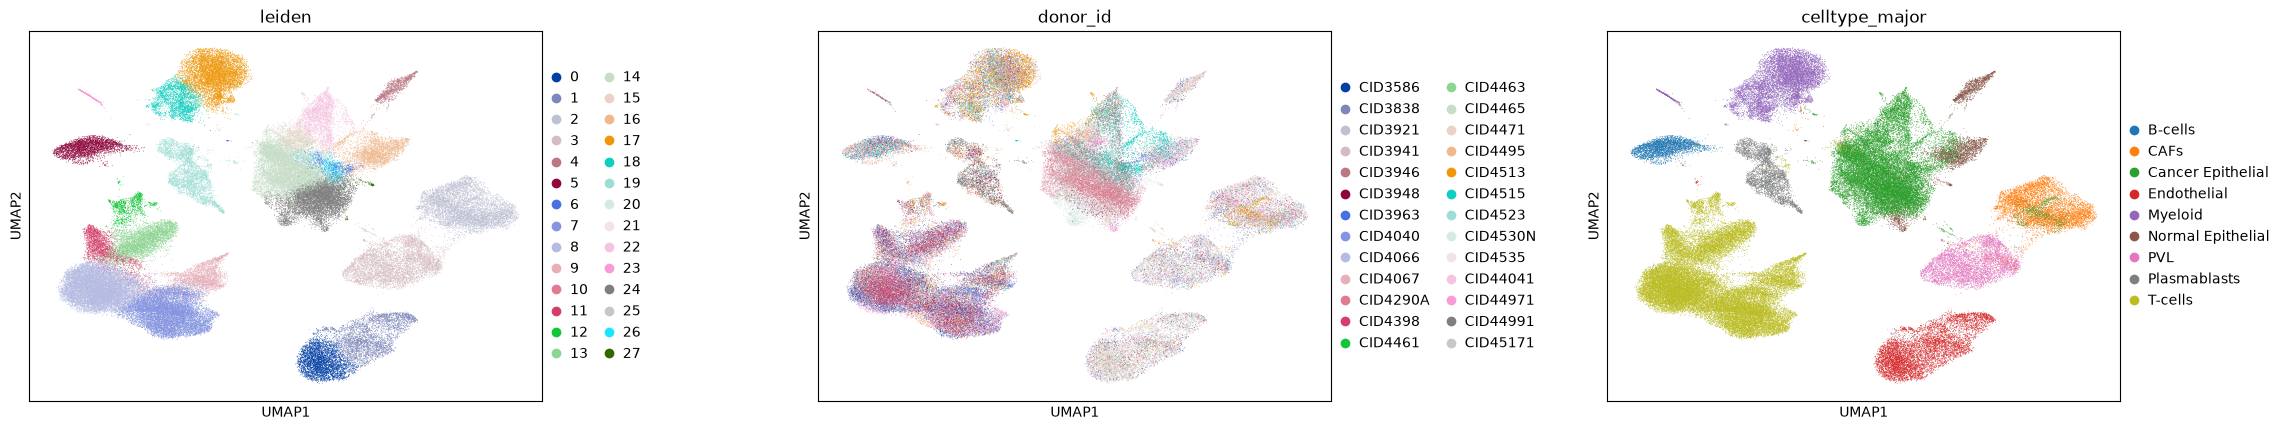

In [16]:
# Color the UMAP three ways:
#  - leiden          : the Leiden clusters
#  - donor_id        : patient, should be INTERMIXED if integration worked (no patient-only blobs)
#  - celltype_major  : authors' published annotation, to validate the clusters
sc.pl.umap(adata, color=["leiden", "donor_id", "celltype_major"], wspace=0.4)

Independent clustering on the Harmony-integrated embedding recovered the authors' published cell types: the 28 Leiden clusters map cleanly onto the nine major populations in `celltype_major` (T-cells, Cancer Epithelial, Myeloid, CAFs, and others), and patients are intermixed within shared populations, confirming successful batch correction, while the malignant compartment retains the expected patient-specific structure.

## 8. Independent cell annotation

Each Leiden cluster is annotated by combining three genuinely independent lines of evidence, selected so that they cannot fail in the same way, followed by a consensus:

1. Canonical markers (`score_genes`), representing marker biology. Specific lineage signatures are used, with shared genes (MHC-II, ribosomal) deliberately excluded so that professional antigen-presenting cells are not conflated.
2. Marker-set enrichment (PanglaoDB with hypergeometric over-representation analysis), representing statistical evidence, corrected for gene-set size so that large database categories are not favoured by their size alone.
3. Reference label transfer (CellTypist), a classifier trained on external annotated atlases that does not use the markers defined here or the authors' labels.

Agreement across independent methods is what makes an annotation trustworthy in the absence of a ground-truth reference. Disagreement is flagged rather than averaged away. Cell states (cycling, interferon) are retained as overlays rather than forced into a lineage. The authors' published labels are used only at the final step, as a one-time check, matching the workflow required for a future dataset without existing annotations.

### 8.1 Method 1: canonical lineage markers (marker biology)

> **Control panel.** This single cell defines every gene set and reference database used in Section 8. Modifying a marker, adding a cell type, adjusting a state signature, or editing the organ filter here propagates to all of Methods 1 to 4 automatically; no gene lists are defined elsewhere in the pipeline.

**Marker and reference definitions (single source of truth).** Every gene set and reference database required by Section 8 is defined and documented in the single cell below; nothing is redefined later. Three components are provided:

- Lineage signatures (cell types, Method 1), curated from CellMarker 2.0 (Hu et al., NAR 2023) and PanglaoDB (Franzen et al., Database 2019); each gene-to-cell-type assignment is traceable to primary literature via its PMID.
- State signatures (cell states, Section 8.4), comprising the cell-cycle program from Tirosh et al. (Science 2016; PMID 27124452) and Seurat `cc.genes`, and the interferon response from the MSigDB Hallmark interferon set (Liberzon 2015).
- PanglaoDB gene sets (`panglao_sets`, the ORA reference for Method 2), drawn from the same PanglaoDB resource and restricted to breast-tumour-relevant compartments.

For every lineage gene, the cell prints the supporting published evidence (the number of supporting records and an example PMID, accessible at `https://pubmed.ncbi.nlm.nih.gov/<PMID>`); any gene lacking support is flagged `CHECK`. Downstream cells (Methods 1 to 4) reference only `LINEAGE_MARKERS`, `STATE_MARKERS`, and `panglao_sets`.

In [17]:
# =============================================================================
# MARKER & REFERENCE DEFINITIONS - single source of truth for ALL of Section 8.
# Define here, document here; downstream cells (Methods 1-4) only REFERENCE these.
# =============================================================================

# --- (A) LINEAGE signatures: cell TYPES (Method 1). Curated from CellMarker 2.0 / PanglaoDB. ---
LINEAGE_MARKERS = {
    "T cell":         ["CD3D", "CD3E", "CD3G", "CD2", "TRAC", "TRBC2"],
    "NK cell":        ["NKG7", "GNLY", "KLRD1", "KLRF1", "NCAM1"],
    "B cell":         ["MS4A1", "CD79A", "CD79B", "BANK1", "CD19"],
    "Plasma cell":    ["MZB1", "JCHAIN", "DERL3", "TNFRSF17", "XBP1"],
    "Myeloid":        ["LYZ", "CD68", "C1QA", "C1QB", "AIF1", "ITGAM"],
    "pDC":            ["LILRA4", "IL3RA", "CLEC4C", "IRF7"],
    "Endothelial":    ["PECAM1", "VWF", "CLDN5", "CDH5", "EGFL7"],
    "Fibroblast/CAF": ["COL1A1", "COL1A2", "DCN", "LUM", "PDGFRA"],
    "Pericyte/PVL":   ["RGS5", "NOTCH3", "ACTA2", "MYH11", "PDGFRB"],
    "Epithelial":     ["EPCAM", "KRT8", "KRT18", "KRT19", "KRT5"],
}

# --- (B) STATE signatures: functional PROGRAMS, not cell types (§8.4 internal check). ---
# cell-cycle: Tirosh et al., Science 2016 (PMID 27124452) / Seurat cc.genes
# interferon: MSigDB Hallmark Interferon Alpha/Gamma Response (Liberzon et al., Cell Systems 2015)
STATE_MARKERS = {
    "cycling": ["MKI67", "TOP2A", "UBE2C", "BIRC5", "CENPF", "STMN1"],
    "ifn":     ["ISG15", "MX1", "IFIT1", "IFIT3", "ISG20", "IFI6", "RSAD2"],
}

# --- (C) ORA reference: PanglaoDB cell-type gene SETS (Method 2). ---
# Franzen et al., Database 2019. Restricted to breast-tumor-relevant compartments.
RELEVANT_ORGANS = ["Immune system", "Mammary gland", "Epithelium", "Connective tissue",
                   "Vasculature", "Smooth muscle", "Blood"]
panglao = dc.op.resource("PanglaoDB", organism="human")
panglao = panglao[panglao["organ"].isin(RELEVANT_ORGANS)]
panglao_sets = panglao.groupby("cell_type")["genesymbol"].apply(set).to_dict()

# --- (D) PROVENANCE check for the lineage markers (counts + PMIDs from CellMarker 2.0) ---
LINEAGE_EXPECT = {
    "T cell":         ["t cell"],
    "NK cell":        ["natural killer", "nk cell"],
    "B cell":         ["b cell"],
    "Plasma cell":    ["plasma"],
    "Myeloid":        ["macrophage", "monocyte", "myeloid", "dendritic", "kupffer"],
    "pDC":            ["plasmacytoid"],
    "Endothelial":    ["endothelial"],
    "Fibroblast/CAF": ["fibroblast"],
    "Pericyte/PVL":   ["pericyte", "mural", "smooth muscle"],
    "Epithelial":     ["epithelial", "luminal", "basal", "mammary", "keratinocyte"],
}

cm = pd.read_csv("../data/human_cell_marker.txt", sep="\t", low_memory=False,
                 usecols=["cell_name", "symbol", "pmid"]).dropna(subset=["symbol", "cell_name"])

rows = []
for lineage, genes in LINEAGE_MARKERS.items():
    pat = "|".join(LINEAGE_EXPECT[lineage])
    for g in genes:
        sub = cm[cm["symbol"] == g]
        match = sub[sub["cell_name"].str.lower().str.contains(pat, na=False)]
        pmids = pd.to_numeric(match["pmid"], errors="coerce").dropna()
        rows.append({
            "lineage": lineage, "gene": g,
            "supporting_records": len(match),
            "example_PMID": int(pmids.iloc[0]) if len(pmids) else None,
            "backed": "yes" if len(match) > 0 else "CHECK",
        })

marker_evidence = pd.DataFrame(rows)
print("LINEAGE markers - published evidence (CellMarker 2.0):")
print(marker_evidence.to_string(index=False))
unbacked = marker_evidence.loc[marker_evidence.backed == "CHECK", "gene"].tolist()
print("Genes with no CellMarker record for their lineage:", unbacked or "none")

print("\nSTATE signatures - functional programs (sources in the note above):")
for k, gs in STATE_MARKERS.items():
    print(f"  {k:8s}: {', '.join(gs)}")

print(f"\nPanglaoDB ORA reference: {len(panglao_sets)} cell-type gene sets "
      f"(organs: {', '.join(RELEVANT_ORGANS)})")

LINEAGE markers - published evidence (CellMarker 2.0):
       lineage     gene  supporting_records  example_PMID backed
        T cell     CD3D                2186      40670619    yes
        T cell     CD3E                1881      40670619    yes
        T cell     CD3G                1283      40670619    yes
        T cell      CD2                1269      40670619    yes
        T cell     TRAC                 938      40670619    yes
        T cell    TRBC2                 898      40670619    yes
       NK cell     NKG7                 725      40670619    yes
       NK cell     GNLY                 723      40670619    yes
       NK cell    KLRD1                 522      40670619    yes
       NK cell    KLRF1                 516      40670619    yes
       NK cell    NCAM1                 622      40670619    yes
        B cell    MS4A1                1746      40670619    yes
        B cell    CD79A                1408      40670619    yes
        B cell    CD79B            

In [18]:
# METHOD 1 - independent evidence: marker BIOLOGY.
# Signatures (LINEAGE_MARKERS) are defined and evidence-checked in the provenance cell above,
# so the list is documented, not arbitrary. Each cluster is scored against them here.

# score every signature per cell (use_raw -> all genes, log-normalized)
for ct, genes in LINEAGE_MARKERS.items():
    sc.tl.score_genes(adata, genes, score_name=f"sig_{ct}", use_raw=True)

clusters = sorted(adata.obs["leiden"].cat.categories, key=int)
sig_cols = [f"sig_{ct}" for ct in LINEAGE_MARKERS]
cluster_scores = adata.obs.groupby("leiden", observed=True)[sig_cols].mean()
cluster_scores.columns = list(LINEAGE_MARKERS)

def marker_call(cl):
    s = cluster_scores.loc[cl].sort_values(ascending=False)
    return s.index[0], s.index[1], round(float(s.iloc[0] - s.iloc[1]), 2)

m1 = pd.DataFrame([(cl, *marker_call(cl)) for cl in clusters],
                  columns=["cluster", "marker_call", "marker_2nd", "marker_margin"])
print(m1.to_string(index=False))

cluster    marker_call     marker_2nd  marker_margin
      0    Endothelial            pDC           1.22
      1    Endothelial            pDC           1.26
      2 Fibroblast/CAF   Pericyte/PVL           2.28
      3   Pericyte/PVL Fibroblast/CAF           0.95
      4   Pericyte/PVL     Epithelial           0.32
      5         B cell            pDC           1.24
      6     Epithelial         B cell           0.87
      7         T cell        NK cell           0.18
      8         T cell            pDC           0.67
      9        NK cell            pDC           1.69
     10         T cell            pDC           0.34
     11         T cell            pDC           0.90
     12         T cell        NK cell           0.36
     13         T cell         B cell           0.92
     14     Epithelial    Plasma cell           0.85
     15     Epithelial        Myeloid           0.82
     16     Epithelial            pDC           1.30
     17        Myeloid            pDC         

### 8.2 Method 2: marker-set enrichment (statistics)

In [19]:
# METHOD 2 - independent evidence: STATISTICS.
# Background-corrected over-representation (hypergeometric) of PanglaoDB cell-type sets among
# each cluster's SPECIFIC data-driven markers. Independent of Method 1: a database + a
# statistical test, not a hand-curated signature.
# (PanglaoDB gene sets `panglao_sets` are defined in the marker-definitions cell above.)

# (a) specific markers per cluster: high IN-cluster but NOT broadly elsewhere
sc.tl.rank_genes_groups(adata, groupby="leiden", method="wilcoxon", use_raw=True, pts=True)
sc.tl.filter_rank_genes_groups(adata, min_in_group_fraction=0.25,
                               max_out_group_fraction=0.5, min_fold_change=1.5)

def clean_markers(cl, n=25):
    arr = adata.uns["rank_genes_groups_filtered"]["names"][cl]
    genes = [g for g in arr if isinstance(g, str)]                 # filtered-out entries = NaN
    genes = [g for g in genes if not g.startswith(("RPS", "RPL", "MRPS", "MRPL", "MT-"))]
    return genes[:n]

# (b) hypergeometric ORA - corrects for set size K so big categories don't win by chance
universe = set(adata.raw.var_names)
def ora_call(cl):
    markers = set(clean_markers(cl)) & universe
    N, n = len(universe), len(markers)
    hits = []
    for ct, gset in panglao_sets.items():
        K, k = len(gset & universe), len(markers & gset)
        if k and K:
            hits.append((ct, hypergeom.sf(k - 1, N, K, n)))
    if not hits:
        return "unresolved", 1.0
    hits.sort(key=lambda x: x[1])
    return hits[0][0], hits[0][1]

m2 = pd.DataFrame([(cl, *ora_call(cl)) for cl in clusters],
                  columns=["cluster", "ora_call", "ora_pval"])
print(m2.to_string(index=False))

/Users/sneha/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/Users/sneha/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/Users/sneha/anaconda3/envs/scrna/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:463: Performanc

cluster                     ora_call     ora_pval
      0            Endothelial cells 3.226157e-29
      1            Endothelial cells 3.119064e-34
      2                  Fibroblasts 1.997582e-20
      3                    Pericytes 1.369286e-13
      4                  Basal cells 1.494839e-16
      5                B cells naive 3.917357e-23
      6             Epithelial cells 6.341821e-06
      7                      T cells 2.506339e-34
      8                      T cells 2.416135e-26
      9                     NK cells 1.890544e-47
     10                    Monocytes 3.353542e-12
     11                      T cells 1.015734e-16
     12          Gamma delta T cells 1.753813e-16
     13               T memory cells 5.457010e-24
     14     Luminal epithelial cells 4.286284e-12
     15             Epithelial cells 6.341821e-06
     16     Mammary epithelial cells 2.135946e-12
     17              Dendritic cells 1.669105e-13
     18              Dendritic cells 2.695491e-22


### 8.3 Method 3: reference label transfer (a classifier trained on external data)

In [20]:
# METHOD 3 - independent evidence: a CLASSIFIER trained on EXTERNAL atlases.
# CellTypist transfers labels from models trained on other people's annotated data - it never
# sees the markers defined here or the authors' labels. NOTE: the public model below is IMMUNE-focused, so
# its vote is trusted for immune clusters and abstains elsewhere (handled in the consensus).
# CellTypist needs log-normalized counts (CP10K) in .X across all genes.
adata_log = adata.raw.to_adata()                       # log-norm CP10K, all genes, same cells
adata_log.obs["leiden"] = adata.obs["leiden"].values

try:
    models.download_models(model=["Immune_All_Low.pkl"])
    model = models.Model.load("Immune_All_Low.pkl")
    pred = celltypist.annotate(adata_log, model=model,
                               majority_voting=True, over_clustering="leiden")
    lt = pred.predicted_labels.copy()
    lt["leiden"] = adata.obs["leiden"].values
    ctmap = {cl: g["majority_voting"].value_counts().index[0]
             for cl, g in lt.groupby("leiden")}
    m3 = pd.DataFrame({"cluster": clusters,
                       "celltypist_call": [ctmap.get(cl, "NA") for cl in clusters]})
except Exception as e:
    print("CellTypist unavailable (consensus will use Methods 1 & 2):", repr(e))
    m3 = pd.DataFrame({"cluster": clusters, "celltypist_call": ["NA"] * len(clusters)})
print(m3.to_string(index=False))

📂 Storing models in /Users/sneha/.celltypist/data/models
💾 Total models to download: 1
⏩ Skipping [1/1]: Immune_All_Low.pkl (file exists)
🔬 Input data has 100028 cells and 26622 genes
🔗 Matching reference genes in the model
🧬 5698 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
🗳️ Majority voting the predictions
✅ Majority voting done!


cluster             celltypist_call
      0           Endothelial cells
      1           Endothelial cells
      2                 Fibroblasts
      3                    NK cells
      4            Epithelial cells
      5              Memory B cells
      6            Epithelial cells
      7   Tem/Trm cytotoxic T cells
      8 Tem/Effector helper T cells
      9              CD16+ NK cells
     10 Tem/Effector helper T cells
     11          Regulatory T cells
     12          Regulatory T cells
     13          Regulatory T cells
     14            Epithelial cells
     15            Epithelial cells
     16            Epithelial cells
     17                 Macrophages
     18                         DC2
     19                Plasma cells
     20                 Macrophages
     21                 Fibroblasts
     22            Epithelial cells
     23                         pDC
     24            Epithelial cells
     25            Epithelial cells
     26            Epithelia

### 8.4 Consensus, confidence, and internal checks

In [21]:
# METHOD 4 - Consensus across the three INDEPENDENT opinions, with internal checks.
# Map each method's label to a common coarse lineage, then take the majority.
# Agreement across independent methods = confidence (no ground truth needed).
def to_lineage(label):
    if not isinstance(label, str):
        return "NA"
    s = label.lower()
    rules = [
        ("pDC",            ["plasmacytoid", "pdc", "lilra4"]),
        ("Plasma cell",    ["plasma", "plasmablast"]),
        ("B cell",         ["b cell", "b-cell", "b cells", "germinal", "memory b", "naive b"]),
        ("NK cell",        ["nk cell", "natural killer", "nk cells", "ilc"]),
        ("T cell",         ["t cell", "t-cell", "t cells", "cd4", "cd8", "treg", "tfh", "thymocyte"]),
        ("Myeloid",        ["macrophage", "monocyte", "myeloid", "dendritic", "kupffer",
                            "microglia", "neutrophil", "mast", "granulocyte", "langerhans"]),
        ("Endothelial",    ["endotheli", "lymphatic"]),
        ("Pericyte/PVL",   ["pericyte", "mural", "pvl", "smooth muscle", "myofibro"]),
        ("Fibroblast/CAF", ["fibroblast", "caf", "stromal", "stellate", "adipocyte"]),
        ("Epithelial",     ["epitheli", "luminal", "basal", "keratinocyte", "ductal",
                            "myoepithel", "mammary", "secretory", "acinar"]),
    ]
    for lineage, keys in rules:
        if any(k in s for k in keys):
            return lineage
    return "Other"

cons = (m1[["cluster", "marker_call"]]
        .merge(m2[["cluster", "ora_call"]], on="cluster")
        .merge(m3, on="cluster"))
cons["M1_markers"]    = cons["marker_call"].map(to_lineage)
cons["M2_ora"]        = cons["ora_call"].map(to_lineage)
cons["M3_celltypist"] = cons["celltypist_call"].map(to_lineage)

IMMUNE = {"T cell", "NK cell", "B cell", "Plasma cell", "Myeloid", "pDC"}
def decide(r):
    votes = [r["M1_markers"], r["M2_ora"]]
    if r["M3_celltypist"] in IMMUNE:           # immune-trained model only votes on immune
        votes.append(r["M3_celltypist"])
    top, n = Counter(votes).most_common(1)[0]
    conf = "high" if n == len(votes) else ("medium" if n >= 2 else "low")
    return pd.Series([top, f"{n}/{len(votes)}", conf])

cons[["final", "agreement", "confidence"]] = cons.apply(decide, axis=1)

# internal check - cycling / interferon are STATES, kept as an overlay (not a lineage)
sc.tl.score_genes(adata, STATE_MARKERS["cycling"], score_name="cycling", use_raw=True)
sc.tl.score_genes(adata, STATE_MARKERS["ifn"], score_name="ifn", use_raw=True)
st = adata.obs.groupby("leiden", observed=True)[["cycling", "ifn"]].mean()
cons["state"] = ["cycling" if st.loc[c, "cycling"] > 0.15 else
                 ("IFN" if st.loc[c, "ifn"] > 0.15 else "") for c in cons["cluster"]]

print(cons[["cluster", "M1_markers", "M2_ora", "M3_celltypist",
            "final", "agreement", "confidence", "state"]].to_string(index=False))

cluster     M1_markers         M2_ora  M3_celltypist          final agreement confidence   state
      0    Endothelial    Endothelial    Endothelial    Endothelial       2/2       high        
      1    Endothelial    Endothelial    Endothelial    Endothelial       2/2       high        
      2 Fibroblast/CAF Fibroblast/CAF Fibroblast/CAF Fibroblast/CAF       2/2       high        
      3   Pericyte/PVL   Pericyte/PVL        NK cell   Pericyte/PVL       2/3     medium        
      4   Pericyte/PVL     Epithelial     Epithelial   Pericyte/PVL       1/2        low        
      5         B cell         B cell         B cell         B cell       3/3       high     IFN
      6     Epithelial     Epithelial     Epithelial     Epithelial       2/2       high        
      7         T cell         T cell         T cell         T cell       3/3       high        
      8         T cell         T cell         T cell         T cell       3/3       high        
      9        NK cell        

In [22]:
# FINAL VALIDATION - the authors' labels enter ONLY now, as a one-time sanity check.
# (In a future unlabeled dataset this cell simply does not exist; you rely on the consensus.)
adata.obs["annotation"] = adata.obs["leiden"].map(
    dict(zip(cons["cluster"], cons["final"]))).astype("category")
print(pd.crosstab(adata.obs["annotation"], adata.obs["celltype_major"]))

celltype_major  B-cells  CAFs  Cancer Epithelial  Endothelial  Myeloid  \
annotation                                                               
B cell             3077     1                  3            0       36   
Endothelial           3     5                  8         7551       34   
Epithelial           11    37              23624            4       21   
Fibroblast/CAF        0  6291                672            2       15   
Myeloid              47     1                 40           18     9232   
NK cell               0     0                  2            0        0   
Pericyte/PVL          0   236                 66            7        1   
Plasma cell          53     2                 36            0        2   
T cell               11     0                 16           20       10   
pDC                   2     0                  0            0      324   

celltype_major  Normal Epithelial   PVL  Plasmablasts  T-cells  
annotation                                    

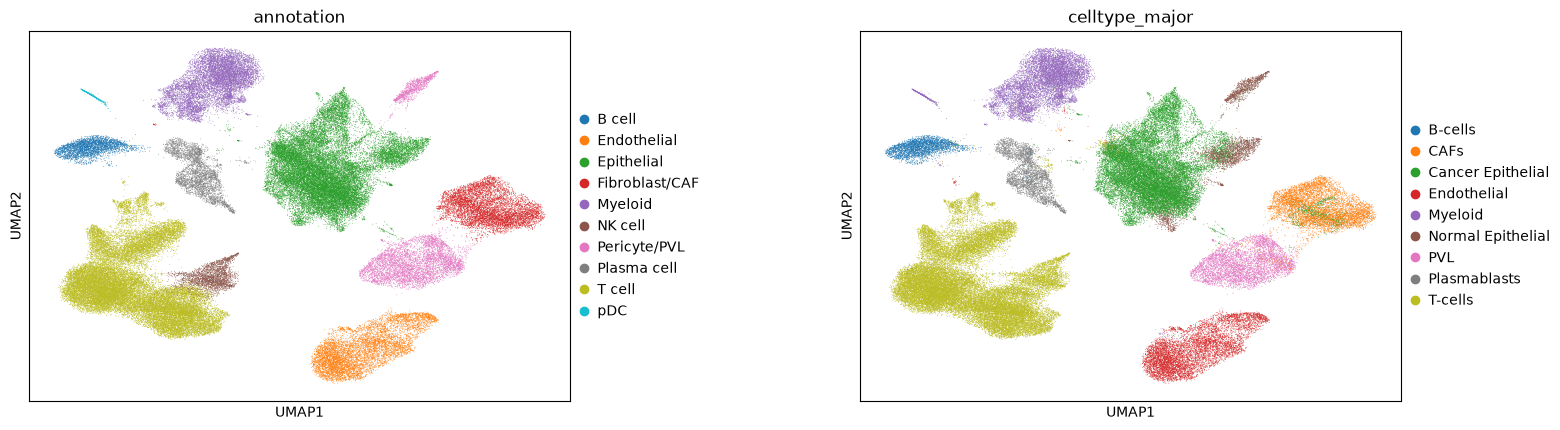

In [23]:
# Visual check: the independent annotation versus the authors' published labels.
sc.pl.umap(adata, color=["annotation", "celltype_major"], wspace=0.4)

## 9. DNA damage response (DDR) at single-cell resolution

The bulk GlncDDR model (Shah et al., Bioinformatics Advances 2026) predicted lncRNAs associated with the
DNA-damage response, but bulk RNA-seq averages over all cells and cannot say where those lncRNAs act. This
section tests a single hypothesis: the predicted lncRNAs are genuine participants in the DNA-damage
response, so at single-cell resolution they should be expressed in the specific tumour cells where DDR is
active, especially malignant cells. The analysis runs in two tiers. A Tier 1 DDR-activity score built from
491 known DDR protein-coding genes (Pearl 2015, Knijnenburg 2018, Weir 2022) provides the reference signal,
and the Tier 2 set of 6,841 predicted DDR-lncRNAs is the subject under test.

### 9.0 Gene sets and provenance (control panel)

Purpose: both components required for the test, a DDR-activity reference and the predicted lncRNAs, are loaded into the dataset together, and the number of each that is detectable is recorded. Both gene sets are defined here and reused throughout Section 9.

In [24]:
# CONTROL PANEL: both DDR gene sets, loaded once and reused across Section 9.
# Tier 1: 491 DDR protein-coding training positives (Pearl 2015 / Knijnenburg 2018 / Weir 2022).
# Tier 2: 6,841 predicted DDR-lncRNAs (all 3 models proba>=0.6, Ensembl-biotype-cleaned to lncRNA).
ddr_df = pd.read_csv("../data/glncddr_ddr_proteins.csv")
lnc_df = pd.read_csv("../data/glncddr_lncrna_clean.csv")

detectable = set(adata.raw.var_names)
DDR_GENES = [g for g in ddr_df["Genes"].unique() if g in detectable]
LNC_GENES = [g for g in lnc_df["Genes"].unique() if g in detectable]
print(f"Tier 1  DDR protein genes : {ddr_df['Genes'].nunique():5d} predicted -> {len(DDR_GENES):5d} detectable")
print(f"Tier 2  DDR lncRNAs       : {lnc_df['Genes'].nunique():5d} predicted -> {len(LNC_GENES):5d} detectable")

Tier 1  DDR protein genes :   491 predicted ->   486 detectable
Tier 2  DDR lncRNAs       :  6841 predicted ->  1165 detectable


Of the 491 curated DDR genes, 486 are captured in this dataset, leaving the DDR reference essentially
complete, whereas only 1,165 of the 6,841 predicted lncRNAs are present. This asymmetry, a near-intact
protein-coding reference against a heavily attrited lncRNA set, shapes the entire section: the DDR proteins
provide a reliable activity yardstick, while the lncRNA findings can only ever speak for the detectable
minority rather than the full prediction.

### 9.1 DDR-activity score (Tier 1)

Purpose: testing whether lncRNAs follow DDR requires a single per-cell measure of how active the DNA-damage response is. `score_genes` collapses the 491 DDR genes into that per-cell score, the reference against which all subsequent steps are measured.

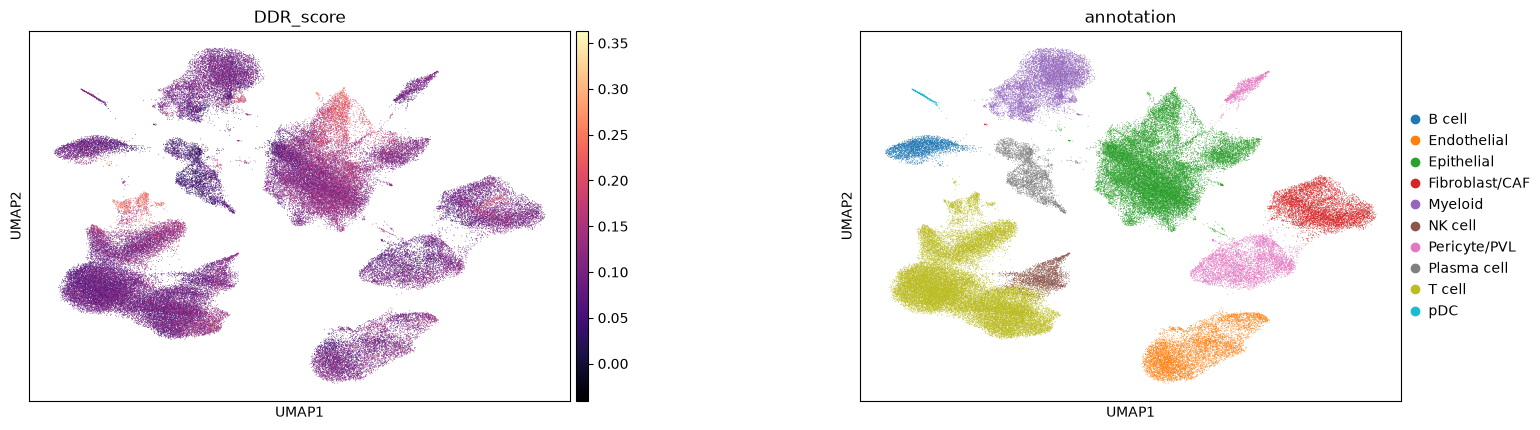

count    100028.000000
mean          0.091747
std           0.042268
min          -0.040397
25%           0.064074
50%           0.088582
75%           0.113754
max           0.363260


In [25]:
sc.tl.score_genes(adata, DDR_GENES, score_name="DDR_score", use_raw=True)
sc.pl.umap(adata, color=["DDR_score", "annotation"], wspace=0.4, cmap="magma")
print(adata.obs["DDR_score"].describe().to_string())

The 491-gene DDR signature resolves into a continuous per-cell activity score that is low in most cells
(median about 0.09) but rises sharply in a minority (up to 0.36), showing that the DNA-damage response is
not a uniform background but a program switched on in a discrete subpopulation. Establishing this per-cell
readout is the prerequisite for the section, because it converts DDR from a tissue-level abstraction into a
quantitative, cell-resolved variable against which the predicted lncRNAs can be tested.

### 9.2 DDR activity across cell types

Purpose: the location of DDR across cell types must be established before the lncRNAs are tested, because a uniform response would render the lncRNA test meaningless. This step maps DDR across the cell types defined independently in Section 8.

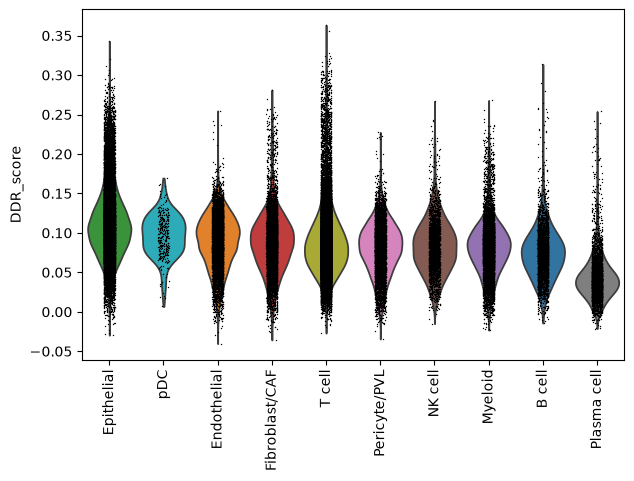

median DDR_score by cell type:
annotation
Epithelial        0.107854
pDC               0.098316
Endothelial       0.092450
Fibroblast/CAF    0.087997
T cell            0.083371
Pericyte/PVL      0.082391
NK cell           0.082036
Myeloid           0.081490
B cell            0.073701
Plasma cell       0.039803


In [26]:
order = (adata.obs.groupby("annotation", observed=True)["DDR_score"]
         .median().sort_values(ascending=False).index.tolist())
sc.pl.violin(adata, "DDR_score", groupby="annotation", order=order, rotation=90)
print("median DDR_score by cell type:")
print(adata.obs.groupby("annotation", observed=True)["DDR_score"].median()
      .sort_values(ascending=False).to_string())

DDR activity is highest in malignant epithelial cells (median 0.108) and lowest in plasma cells
(0.040), with the remaining lineages clustered narrowly in between, consistent with the DDR program being
coupled to proliferation: pronounced in continuously dividing tumour cells and minimal in terminally
differentiated plasma cells. The long upper tails of the epithelial and T-cell distributions localise the
most DDR-intense cells to the malignant compartment and a smaller activated T-cell fraction, identifying
the epithelial compartment as the place where DDR-associated lncRNAs are most likely to be found.

### 9.3 DDR in malignant cells by molecular subtype

Purpose: a validation check on the DDR score. If the score is biologically meaningful it should reproduce known clinical biology, so DDR activity is compared across TNBC, HER2+, and ER+ malignant cells.

median DDR_score in malignant cells by subtype:
subtype
ER+      0.097085
HER2+    0.120823
TNBC     0.130740

Kruskal-Wallis across subtypes: H=3753.2, p=0.00e+00


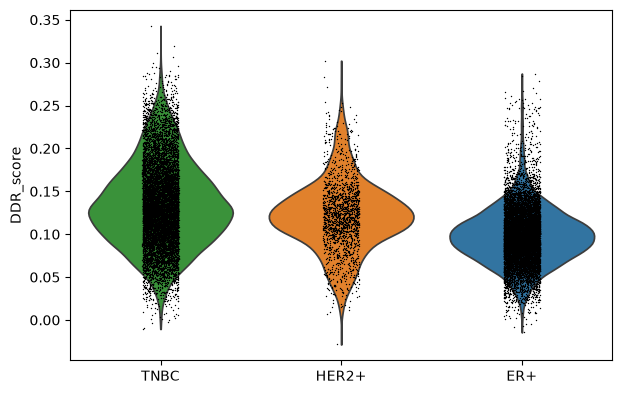

In [27]:
from scipy.stats import kruskal
mal = adata[adata.obs["celltype_major"] == "Cancer Epithelial"].copy()
subs = ["TNBC", "HER2+", "ER+"]
groups = [mal.obs.loc[mal.obs["subtype"] == s, "DDR_score"].values for s in subs]
H, p = kruskal(*groups)
print("median DDR_score in malignant cells by subtype:")
print(mal.obs.groupby("subtype", observed=True)["DDR_score"].median().to_string())
print(f"\nKruskal-Wallis across subtypes: H={H:.1f}, p={p:.2e}")
sc.pl.violin(mal, "DDR_score", groupby="subtype", order=subs, rotation=0)

Within malignant cells, DDR activity follows a clear molecular-subtype gradient (TNBC 0.131, HER2+
0.121, ER+ 0.097) that recapitulates established clinical biology: triple-negative tumours are enriched for
homologous-recombination deficiency and are the principal indication for PARP-inhibitor therapy, whereas
ER+ tumours are the most genomically stable. Because this independently derived score reproduces a known
therapeutic axis, it serves as a trustworthy reference for the lncRNA analysis that follows. The very large
cell count renders the formal p-value uninformative, and the patient-level nature of subtype means the
gradient is read as a between-tumour trend.

### 9.4 Are the predicted lncRNAs even detectable? (Tier 2)

Purpose: a lncRNA cannot be called present or absent in a cell type if the assay cannot see it, so this
step measures how many predicted lncRNAs are detectable before any biological claim is made.

In [28]:
import numpy as np
Xl = adata.raw[:, LNC_GENES].X
frac = np.asarray((Xl > 0).mean(axis=0)).ravel()
audit = pd.DataFrame({"lncRNA": LNC_GENES, "pct_cells": 100 * frac})
print(f"Detectable lncRNAs: {len(LNC_GENES)} of {lnc_df['Genes'].nunique()} predicted")
print(f"  expressed in >=1%  of cells: {(frac >= 0.01).sum()}")
print(f"  expressed in >=10% of cells: {(frac >= 0.10).sum()}")
print("\nmost broadly detected predicted lncRNAs:")
print(audit.sort_values("pct_cells", ascending=False).head(10).to_string(index=False))
sc.tl.score_genes(adata, LNC_GENES, score_name="lncRNA_score", use_raw=True)

Detectable lncRNAs: 1165 of 6841 predicted
  expressed in >=1%  of cells: 200
  expressed in >=10% of cells: 17

most broadly detected predicted lncRNAs:
    lncRNA  pct_cells
    MALAT1  98.532411
     ZFAS1  64.330987
     NORAD  32.092014
    SNHG32  30.584436
    SNHG12  27.973168
   TP53TG1  20.691206
     CRNDE  19.862439
  FGD5-AS1  18.177910
 PSMA3-AS1  17.590075
NUTM2A-AS1  15.786580


Only 200 of the predicted lncRNAs are expressed in at least 1% of cells and just 17 in at least 10%,
and the most broadly detected are abundant, largely housekeeping lncRNAs such as MALAT1 (about 99% of
cells). This reflects the intrinsic sensitivity limit of droplet single-cell RNA-seq for low-abundance
transcripts rather than a failure of prediction, and it bounds the downstream analysis to roughly 200
testable lncRNAs while establishing that non-detection here cannot be read as evidence against a
prediction.

### 9.5 Do the predicted lncRNAs track DDR activity?

Purpose: the core test of the hypothesis. If the predicted lncRNAs are genuine DDR participants, their
expression should rise in the same cells where the DDR score is high.

In [29]:
from scipy.stats import spearmanr
rho, pv = spearmanr(adata.obs["lncRNA_score"], adata.obs["DDR_score"])
print(f"lncRNA program vs DDR program (all cells): Spearman rho={rho:.3f}, p={pv:.1e}")

y = adata.obs["DDR_score"].values.astype(float); yz = y - y.mean(); n = Xl.shape[0]
xmean = np.asarray(Xl.mean(axis=0)).ravel()
xvar = np.asarray(Xl.multiply(Xl).mean(axis=0)).ravel() - xmean**2
cov = np.asarray(Xl.T.dot(yz)).ravel() / n
corr = cov / (np.sqrt(np.maximum(xvar, 1e-12)) * y.std() + 1e-12)
res = (pd.DataFrame({"lncRNA": LNC_GENES, "corr_with_DDR": corr, "pct_cells": 100 * frac})
       .query("pct_cells >= 1").sort_values("corr_with_DDR", ascending=False))
print(f"\nPredicted lncRNAs (>=1% cells) with corr>0.1 -> {(res['corr_with_DDR']>0.1).sum()}")
print("\nTop 15 DDR-tracking predicted lncRNAs:")
print(res.head(15).to_string(index=False))
res.to_csv("../data/glncddr_lncrna_DDRcorr.csv", index=False)

lncRNA program vs DDR program (all cells): Spearman rho=-0.626, p=0.0e+00

Predicted lncRNAs (>=1% cells) with corr>0.1 -> 23

Top 15 DDR-tracking predicted lncRNAs:
    lncRNA  corr_with_DDR  pct_cells
SPINT1-AS1       0.227972  15.106770
     CRNDE       0.213883  19.862439
 LINC01133       0.193918   4.754669
 LINC00221       0.192024   2.211381
 LINC00665       0.179179  11.275843
     NORAD       0.146073  32.092014
   WAC-AS1       0.128200  13.077338
     DLEU2       0.125384   6.188267
    SNHG10       0.119314   6.930060
 LINC00393       0.118611   1.013716
   TP53TG1       0.117340  20.691206
ATP2A1-AS1       0.116950   1.485584
    SNHG32       0.116324  30.584436
     DSCR8       0.116269   1.574559
 LINC02303       0.113302   1.683529


The module-level negative correlation (Spearman about -0.63) is an artefact of the lncRNA score being
dominated by the ubiquitous transcript MALAT1 and is therefore discounted. The informative result is that
23 individual predicted lncRNAs correlate positively with DDR activity (r > 0.1), led by NORAD and TP53TG1.
Both are established DNA-damage-response lncRNAs (NORAD is induced by DNA damage to preserve genomic
stability, and TP53TG1 is a p53 transcriptional target), so their recovery as DDR-correlated transcripts
independently corroborates the GlncDDR predictions at single-cell resolution, albeit with modest
correlations (r about 0.1 to 0.23) that may partly reflect proliferation. Because the 9.5 correlation is computed across all cells, it can be inflated by cell-type composition, so the proliferation-controlled, within-malignant test in 9.7 examines whether it reflects a DDR-specific signal.

### 9.6 Cell-type localisation of the predicted lncRNAs (the end goal)

Purpose: this is the question bulk RNA-seq could not address and the central single-cell advance, namely which cell types express the detectable predicted lncRNAs. Each lncRNA is assigned the cell type in which it is most highly expressed, and the DDR-tracking lncRNAs are then examined for localisation to the high-DDR malignant compartment.

In [30]:
# (a) per-cell-type expression of the detectable (>=1% cells) lncRNAs
det = [g for g, m in zip(LNC_GENES, frac >= 0.01) if m]
print(f"localising {len(det)} lncRNAs across cell types\n")
df = sc.get.obs_df(adata, keys=det, use_raw=True)
ann = adata.obs["annotation"].values
mean_by_ct = df.groupby(ann).mean()                 # cell type x lncRNA  (mean expression)
pct_by_ct  = (df > 0).groupby(ann).mean() * 100      # cell type x lncRNA  (percent expressing)
home = mean_by_ct.idxmax(axis=0)                     # each lncRNA's dominant cell type
print("HOME cell type of the detectable lncRNAs (where each is most expressed):")
print(home.value_counts().to_string())

localising 200 lncRNAs across cell types

HOME cell type of the detectable lncRNAs (where each is most expressed):
Epithelial        78
Fibroblast/CAF    25
pDC               22
Endothelial       19
NK cell           12
Pericyte/PVL      12
Myeloid            9
T cell             9
B cell             7
Plasma cell        7


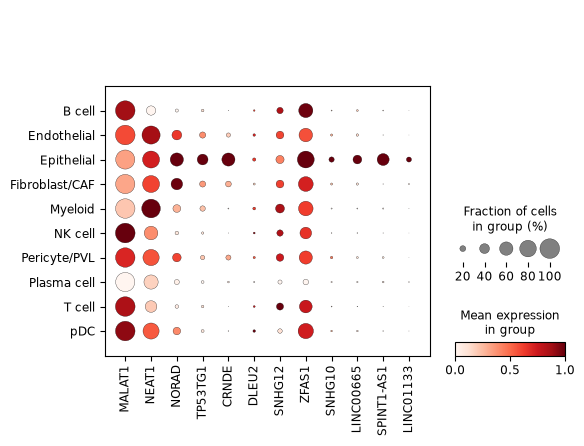

In [31]:
# (b) dotplot: key lncRNAs by cell type  (dot size = percent expressing, colour = mean expression)
key = ["MALAT1", "NEAT1", "NORAD", "TP53TG1", "CRNDE", "DLEU2", "SNHG12", "ZFAS1",
       "SNHG10", "LINC00665", "SPINT1-AS1", "LINC01133"]
key = [g for g in key if g in adata.raw.var_names]
sc.pl.dotplot(adata, key, groupby="annotation", use_raw=True, standard_scale="var")

In [32]:
# (c) do the DDR-tracking lncRNAs (from 9.5) live in the malignant / high-DDR compartment?
top_ddr = [g for g in res.head(15)["lncRNA"] if g in mean_by_ct.columns]
loc = pd.DataFrame({
    "lncRNA":           top_ddr,
    "home_cell_type":   [home[g] for g in top_ddr],
    "pct_Epithelial":   [round(pct_by_ct.loc["Epithelial", g], 1) for g in top_ddr],
    "pct_Tcell":        [round(pct_by_ct.loc["T cell", g], 1) for g in top_ddr],
})
print(loc.to_string(index=False))

    lncRNA home_cell_type  pct_Epithelial  pct_Tcell
SPINT1-AS1     Epithelial            51.8        0.6
     CRNDE     Epithelial            58.3        0.5
 LINC01133     Epithelial            16.4        0.1
 LINC00221     Epithelial             7.9        0.1
 LINC00665     Epithelial            34.1        1.2
     NORAD     Epithelial            59.0       10.4
   WAC-AS1     Epithelial            26.3        4.3
     DLEU2            pDC             9.1        4.4
    SNHG10     Epithelial            17.5        1.8
 LINC00393     Epithelial             3.6        0.0
   TP53TG1     Epithelial            44.9        6.6
ATP2A1-AS1     Epithelial             4.0        0.5
    SNHG32 Fibroblast/CAF            44.5       18.9
     DSCR8     Epithelial             5.7        0.0
 LINC02303     Epithelial             6.0        0.0


Mapping each detectable lncRNA to the cell type in which it is most expressed assigns every transcript a defined cellular origin, and the focused table places the DDR-correlated lncRNAs within that map. Of the roughly 200 detectable lncRNAs, the largest group (78) is expressed predominantly in malignant epithelial cells, more than three times the next compartment (Fibroblast/CAF, 25), and 13 of the 15 DDR-tracking lncRNAs identified in 9.5 home to that same epithelial compartment. The two canonical DDR lncRNAs are well represented there, NORAD in 59.0% and TP53TG1 in 44.9% of cancer epithelial cells, against only 10.4% and 6.6% of T cells respectively. This localisation is the central single-cell advance of the study: where the bulk GlncDDR model could only assert that these lncRNAs are DDR-associated, the single-cell data place that association in the malignant epithelial cells where the DNA-damage response is most active (9.2), closing the loop from prediction to cell-resolved expression.

### 9.7 Is the lncRNA-to-DDR association independent of proliferation?

Purpose: the correlations in 9.5 could arise simply because both DDR and many lncRNAs are elevated in dividing cells. To determine whether the association is DDR-specific, the analysis is restricted to malignant cells, and for each DDR-tracking lncRNA the partial correlation between its expression and the DDR score is computed after controlling for the cell-cycle (cycling) score.

In [33]:
# 9.7 partial correlation of lncRNA vs DDR, controlling for proliferation, within malignant cells
mal = adata[adata.obs["celltype_major"] == "Cancer Epithelial"].copy()
Xm = mal.raw[:, det].X
ddr = mal.obs["DDR_score"].values.astype(float)
cyc = mal.obs["cycling"].values.astype(float)

def vcorr(X, yv):                                  # Pearson of each column of sparse X with vector yv
    y0 = yv - yv.mean(); nn = X.shape[0]
    xm = np.asarray(X.mean(0)).ravel()
    xv = np.asarray(X.multiply(X).mean(0)).ravel() - xm**2
    cov = np.asarray(X.T.dot(y0)).ravel() / nn
    return cov / (np.sqrt(np.maximum(xv, 1e-12)) * yv.std() + 1e-12)

r_xy = vcorr(Xm, ddr)                              # lncRNA vs DDR
r_xz = vcorr(Xm, cyc)                              # lncRNA vs cycling
r_yz = np.corrcoef(ddr, cyc)[0, 1]                 # DDR vs cycling
partial = (r_xy - r_xz * r_yz) / np.sqrt(np.maximum((1 - r_xz**2) * (1 - r_yz**2), 1e-12))

out = pd.DataFrame({"lncRNA": det, "r_DDR": r_xy, "r_cycling": r_xz,
                    "partial_DDR_given_cycling": partial})
hits = (out[out["lncRNA"].isin(res.head(15)["lncRNA"])]
        .sort_values("partial_DDR_given_cycling", ascending=False))
print(f"DDR vs cycling correlation within malignant cells: r={r_yz:.2f}\n")
print(hits.round(3).to_string(index=False))

DDR vs cycling correlation within malignant cells: r=0.55

    lncRNA  r_DDR  r_cycling  partial_DDR_given_cycling
   WAC-AS1  0.123      0.028                      0.130
 LINC00221  0.230      0.230                      0.128
 LINC00665  0.122      0.032                      0.125
SPINT1-AS1  0.129      0.047                      0.123
    SNHG10  0.150      0.090                      0.121
 LINC01133  0.188      0.180                      0.108
 LINC00393  0.143      0.104                      0.103
ATP2A1-AS1  0.133      0.095                      0.098
    SNHG32  0.118      0.071                      0.095
 LINC02303  0.106      0.060                      0.087
     CRNDE  0.077      0.017                      0.081
     NORAD  0.016     -0.088                      0.078
     DLEU2  0.157      0.188                      0.065
     DSCR8  0.103      0.109                      0.052
   TP53TG1 -0.100     -0.190                      0.005


Within malignant cells, DDR and proliferation are themselves moderately correlated (r = 0.55), because the 491-gene DDR set includes replication and cell-cycle genes, so the DDR score is partly a proliferation readout. Against this stricter test the picture changes markedly. The canonical DDR lncRNAs do not retain a DDR-specific association inside the malignant compartment: NORAD falls to a partial correlation of 0.08 and TP53TG1 to 0.005, indicating that their apparent DDR tracking in 9.5 was driven largely by cell-type composition, since both are highly expressed in cancer cells and cancer cells carry high DDR, rather than by cell-to-cell DDR variation within the tumour. A small number of other predicted lncRNAs (LINC00665, SPINT1-AS1, WAC-AS1, SNHG10) retain weak positive partial correlations around 0.12 to 0.13 that are not explained by proliferation, making them the better, if modest, candidates for a proliferation-independent DDR association. At the sensitivity of this dataset the predicted DDR-lncRNAs therefore show at most weak DDR-specific coupling within cancer cells, and the well-known DDR lncRNAs are not the ones that retain it.

### 9.8 Overall synthesis and limits

End to end, the section builds a DDR-activity score from 491 DDR genes that behaves as expected, highest in
malignant epithelial cells (9.2) and following the clinical TNBC, HER2+, ER+ gradient that underpins
PARP-inhibitor therapy (9.3). Most predicted lncRNAs are undetectable in single cells (9.4), a sensitivity
limit rather than a biological one. Among the detectable subset, expression localises predominantly to the
malignant epithelial compartment (9.6), and this is the robust single-cell finding: the predicted
DDR-lncRNAs, including NORAD and TP53TG1, are expressed in the cancer cells where DDR activity is highest.

The association with DDR is more nuanced. Across all cells the lncRNAs co-vary with DDR (9.5), but the
proliferation-controlled, within-malignant test (9.7) shows that this is largely a cell-type composition
effect: inside cancer cells the canonical DDR lncRNAs lose their DDR-specific signal, and only a few
predicted lncRNAs retain weak, proliferation-independent associations. The supported claim is therefore
that detectable predicted DDR-lncRNAs are expressed in specific breast-tumour cell types, predominantly the
malignant epithelial cells where DDR is most active, which is the resolution bulk RNA-seq could not provide.
The data do not support a strong claim of cell-intrinsic DDR regulation: co-expression is association rather
than causation, the DDR score is partly entangled with proliferation (DDR versus cycling r = 0.55 in cancer
cells), lncRNA dropout caps coverage, and within-tumour DDR-specific coupling is weak. The clearest
single-cell advance is localisation, assigning the predicted DDR-lncRNAs to the malignant compartment.

## Conclusion

This single-cell reanalysis directly identifies a set of GlncDDR-predicted lncRNAs that are expressed predominantly in the malignant epithelial cells of the breast tumour microenvironment, including NORAD, CRNDE, SPINT1-AS1, TP53TG1, and LINC00665, each detected in 34 to 59% of cancer cells. Assigning the predicted DDR-lncRNAs to a specific cell population is the principal result of the study and the resolution that bulk RNA-seq could not provide; these cancer-cell-associated transcripts are the concrete candidates for further analysis.

A separate, weaker question, whether these lncRNAs track DDR activity cell-by-cell within the tumour, is not resolved in their favour. Across the whole tissue the co-variation between lncRNA expression and DDR activity is driven largely by shared cell-type localisation, and within cancer cells, after controlling for proliferation, the canonical DDR lncRNAs NORAD and TP53TG1 retain no DDR-specific signal, while only LINC00665, SPINT1-AS1, WAC-AS1, and SNHG10 show a weak, proliferation-independent association.

In summary, the bulk GlncDDR predictions extend to single-cell resolution as a localisation result: specific predicted lncRNAs are confirmed to be expressed in the malignant compartment where DDR is active, providing a prioritised candidate list for targeted experimental validation, whereas a direct, cell-intrinsic regulatory role for these lncRNAs in the DNA-damage response is not established by the present data and remains to be tested.